# Localization Sampling Budget Ablation: Aggregate Production Figures and Final Paper Table

This notebook is the paper-facing companion to `localization_sampling_budget_ablation.py` for the **100-example aggregate run**.

**Default input bundle**
- `datasetmain_localization_sampling_budget_ablation_outputs/qwen7b_short_deceptive_100`

**What this notebook now produces**
1. A main aggregate figure for the paper: estimation error, coverage, and structural agreement vs sampling budget.
2. A second production figure showing the full error distribution, example-level heterogeneity, and environment-level heterogeneity.
3. The final table to report in the paper, with compact confidence intervals and a LaTeX export.
4. Optional appendix diagnostics to help write the results section.

By default, the notebook renders everything inline and does **not** create extra files. Set `SAVE_ARTIFACTS = True` if you want the figures written out.

In [1]:
from pathlib import Path
import textwrap

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.precision", 3)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

OUTPUT_ROOT = Path(
    "/playpen-ssd/smerrill/deception2/Notebooks/"
    "datasetmain_localization_sampling_budget_ablation_outputs/qwen7b_short_deceptive_100"
)
SAVE_ARTIFACTS = False
ARTIFACT_DIR = OUTPUT_ROOT / "paper_artifacts"


def maybe_savefig(fig, filename: str) -> None:
    if SAVE_ARTIFACTS:
        ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(ARTIFACT_DIR / filename, bbox_inches="tight")


def fmt_float(value: float, digits: int = 3) -> str:
    return f"{float(value):.{digits}f}"


def fmt_pct(value: float, digits: int = 1) -> str:
    return f"{100 * float(value):.{digits}f}%"


def fmt_ci(center: float, low: float, high: float, digits: int = 3) -> str:
    return f"{center:.{digits}f} [{low:.{digits}f}, {high:.{digits}f}]"


def fmt_ci_pct(center: float, low: float, high: float, digits: int = 1) -> str:
    return f"{100 * center:.{digits}f}% [{100 * low:.{digits}f}, {100 * high:.{digits}f}]"


def wrap_text(text: str, width: int = 90) -> str:
    return textwrap.shorten(str(text).replace("\n", " "), width=width, placeholder="...")


In [2]:
required = {
    "config": OUTPUT_ROOT / "config.csv",
    "candidate_counts": OUTPUT_ROOT / "candidate_counts_by_env.csv",
    "selection_counts": OUTPUT_ROOT / "selection_counts_by_env.csv",
    "selected_examples": OUTPUT_ROOT / "selected_examples.csv",
    "budget_prefix": OUTPUT_ROOT / "budget_summary_prefix.csv",
    "budget_agreement": OUTPUT_ROOT / "budget_summary_example_agreement.csv",
    "paper_summary": OUTPUT_ROOT / "paper_budget_summary.csv",
    "prefix_summary": OUTPUT_ROOT / "prefix_summary.csv",
    "prefix_repeat": OUTPUT_ROOT / "prefix_repeat_samples.csv",
    "example_repeat": OUTPUT_ROOT / "example_repeat_agreement.csv",
}

missing = [name for name, path in required.items() if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing expected files: {missing}")

config = pd.read_csv(required["config"])
candidate_counts = pd.read_csv(required["candidate_counts"])
selection_counts = pd.read_csv(required["selection_counts"])
selected_examples = pd.read_csv(required["selected_examples"])
budget_prefix = pd.read_csv(required["budget_prefix"])
budget_agreement = pd.read_csv(required["budget_agreement"])
paper_summary = pd.read_csv(required["paper_summary"])
prefix_summary = pd.read_csv(required["prefix_summary"])
prefix_repeat = pd.read_csv(
    required["prefix_repeat"],
    usecols=["example_key", "env_name", "n_samples", "abs_diff_vs_reference"],
)
example_repeat = pd.read_csv(required["example_repeat"])

for df in [budget_prefix, budget_agreement, paper_summary, prefix_summary, prefix_repeat, example_repeat]:
    df["n_samples"] = df["n_samples"].astype(int)

paper_summary["reference_sample_size"] = paper_summary["reference_sample_size"].astype(int)
budgets = sorted(paper_summary["n_samples"].astype(int).unique())
reference_budget = max(budgets)
eval_budgets = [budget for budget in budgets if budget != reference_budget]
smallest_budget = min(eval_budgets)

config_map = dict(zip(config["setting"], config["value"]))
jump_threshold = float(config_map.get("jump_agreement_min_reference_magnitude", 0.0))
jump_filtered_available = (
    jump_threshold > 0.0
    and "jump_within_one_ref_jump_ge_threshold" in paper_summary.columns
)
jump_within_metric = "jump_within_one_ref_jump_ge_threshold" if jump_filtered_available else "jump_within_one"
jump_within_low_col = "jump_within_one_ref_jump_ge_threshold_ci_low" if jump_filtered_available else "jump_within_one_ci_low"
jump_within_high_col = "jump_within_one_ref_jump_ge_threshold_ci_high" if jump_filtered_available else "jump_within_one_ci_high"
jump_metric_label = (
    f"Jump agreement (within 1, ref jump >= {jump_threshold:g})"
    if jump_filtered_available
    else "Jump agreement (within 1)"
)
jump_curve_label = (
    f"Largest jump within one (ref jump >= {jump_threshold:g})"
    if jump_filtered_available
    else "Largest jump within one"
)
env_order = selection_counts.sort_values("selected_examples", ascending=False)["env_name"].tolist()

budget_colors = {
    smallest_budget: "#C44E52",
    25: "#DD8452",
    50: "#4C72B0",
    reference_budget: "#1A1A1A",
}
env_colors = {
    "AdvisorAudit": "#4C72B0",
    "BS": "#55A868",
    "CarSales": "#C44E52",
    "Gridworld": "#8172B3",
    "Interview": "#CCB974",
}

paper_nonref = paper_summary.loc[paper_summary["n_samples"].isin(eval_budgets)].sort_values("n_samples").reset_index(drop=True)
reference_prefixes = prefix_summary.loc[prefix_summary["n_samples"].eq(reference_budget)].copy()
candidate_total = int(candidate_counts["short_label_examples"].sum())
selected_total = int(selected_examples["example_key"].nunique())
jump_eligible_examples = (
    int(paper_summary["jump_eligible_examples"].max()) if jump_filtered_available else selected_total
)
jump_metric_note = (
    f"This jump metric is evaluated on {jump_eligible_examples}/{selected_total} examples whose reference largest positive jump is at least {jump_threshold:g}."
    if jump_filtered_available
    else ""
)
prefix_total = int(paper_summary["num_prefixes"].max())
mean_sentences_per_example = float(prefix_total / selected_total)
mean_valid_reference = float(paper_summary["mean_valid_reference"].iloc[0])

selected_examples_by_env = selection_counts.set_index("env_name")["selected_examples"].reindex(env_order)
reference_prefixes_by_env = reference_prefixes.groupby("env_name").size().reindex(env_order)

env_budget_mae = (
    prefix_summary.loc[prefix_summary["n_samples"].isin(eval_budgets)]
    .groupby(["env_name", "n_samples"])["mean_abs_diff_vs_reference"]
    .mean()
    .unstack()
    .reindex(env_order)
)
env_budget_cover10 = (
    prefix_summary.loc[prefix_summary["n_samples"].isin(eval_budgets)]
    .groupby(["env_name", "n_samples"])["prob_within_0_10"]
    .mean()
    .unstack()
    .reindex(env_order)
)

example_budget_mae = (
    prefix_summary.groupby(["example_key", "example_id", "env_name", "n_samples"], as_index=False)["mean_abs_diff_vs_reference"]
    .mean()
)
example_budget_mae = example_budget_mae.loc[example_budget_mae["n_samples"].isin(eval_budgets)].copy()

baseline_row = paper_nonref.loc[paper_nonref["n_samples"].eq(smallest_budget)].iloc[0]
best_row = paper_nonref.iloc[-1]
hardest_env = env_budget_mae[smallest_budget].astype(float).idxmax()
hardest_env_mae = float(env_budget_mae[smallest_budget].astype(float).max())
hardest_example = (
    example_budget_mae.loc[example_budget_mae["n_samples"].eq(smallest_budget)]
    .sort_values("mean_abs_diff_vs_reference", ascending=False)
    .iloc[0]
)


FileNotFoundError: Missing expected files: ['config', 'candidate_counts', 'selection_counts', 'selected_examples', 'budget_prefix', 'budget_agreement', 'paper_summary', 'prefix_summary', 'prefix_repeat', 'example_repeat']

In [3]:
run_summary = pd.DataFrame(
    [
        ("Model", config_map["model_dirname"]),
        ("Environments", config_map["envs"]),
        ("Candidate short deceptive examples", candidate_total),
        ("Selected examples", selected_total),
        ("Localized prefixes", prefix_total),
        ("Mean sentences per example", f"{mean_sentences_per_example:.2f}"),
        ("Reference budget", f"{reference_budget} continuations per prefix"),
        ("Mean valid outcomes in reference", f"{mean_valid_reference:.2f}"),
        (
            "Jump-agreement filter",
            (
                f"Reference largest positive jump >= {jump_threshold:g} ({jump_eligible_examples}/{selected_total} examples)"
                if jump_filtered_available
                else "All selected examples"
            ),
        ),
    ],
    columns=["Field", "Value"],
)
display(run_summary)

mae_reduction = 1.0 - (float(best_row["mean_abs_diff_vs_reference"]) / float(baseline_row["mean_abs_diff_vs_reference"]))
takeaways = [
    "### Draft-ready quantitative takeaways",
    f"- The aggregate evaluation covers **{selected_total} examples** and **{prefix_total} localized prefixes** across five environments.",
    f"- Increasing the continuation budget from **{smallest_budget}** to **{int(best_row['n_samples'])}** reduces mean absolute error from **{baseline_row['mean_abs_diff_vs_reference']:.3f}** to **{best_row['mean_abs_diff_vs_reference']:.3f}**, a **{mae_reduction:.1%}** reduction.",
    f"- At **{int(best_row['n_samples'])}** samples, **{fmt_pct(best_row['frac_within_0_10'])}** of prefixes are within 0.10 of the {reference_budget}-sample reference, compared with **{fmt_pct(baseline_row['frac_within_0_10'])}** at **{smallest_budget}** samples.",
    f"- Structural recovery also improves substantially: peak-sentence agreement within one sentence rises from **{fmt_pct(baseline_row['peak_within_one'])}** to **{fmt_pct(best_row['peak_within_one'])}**, and {jump_metric_label.lower()} rises from **{fmt_pct(baseline_row[jump_within_metric])}** to **{fmt_pct(best_row[jump_within_metric])}**. {jump_metric_note}",
    f"- The hardest environment at the smallest budget is **{hardest_env}**, with mean absolute error **{hardest_env_mae:.3f}**.",
]
display(Markdown("\n".join(takeaways)))


NameError: name 'config_map' is not defined

NameError: name 'paper_nonref' is not defined

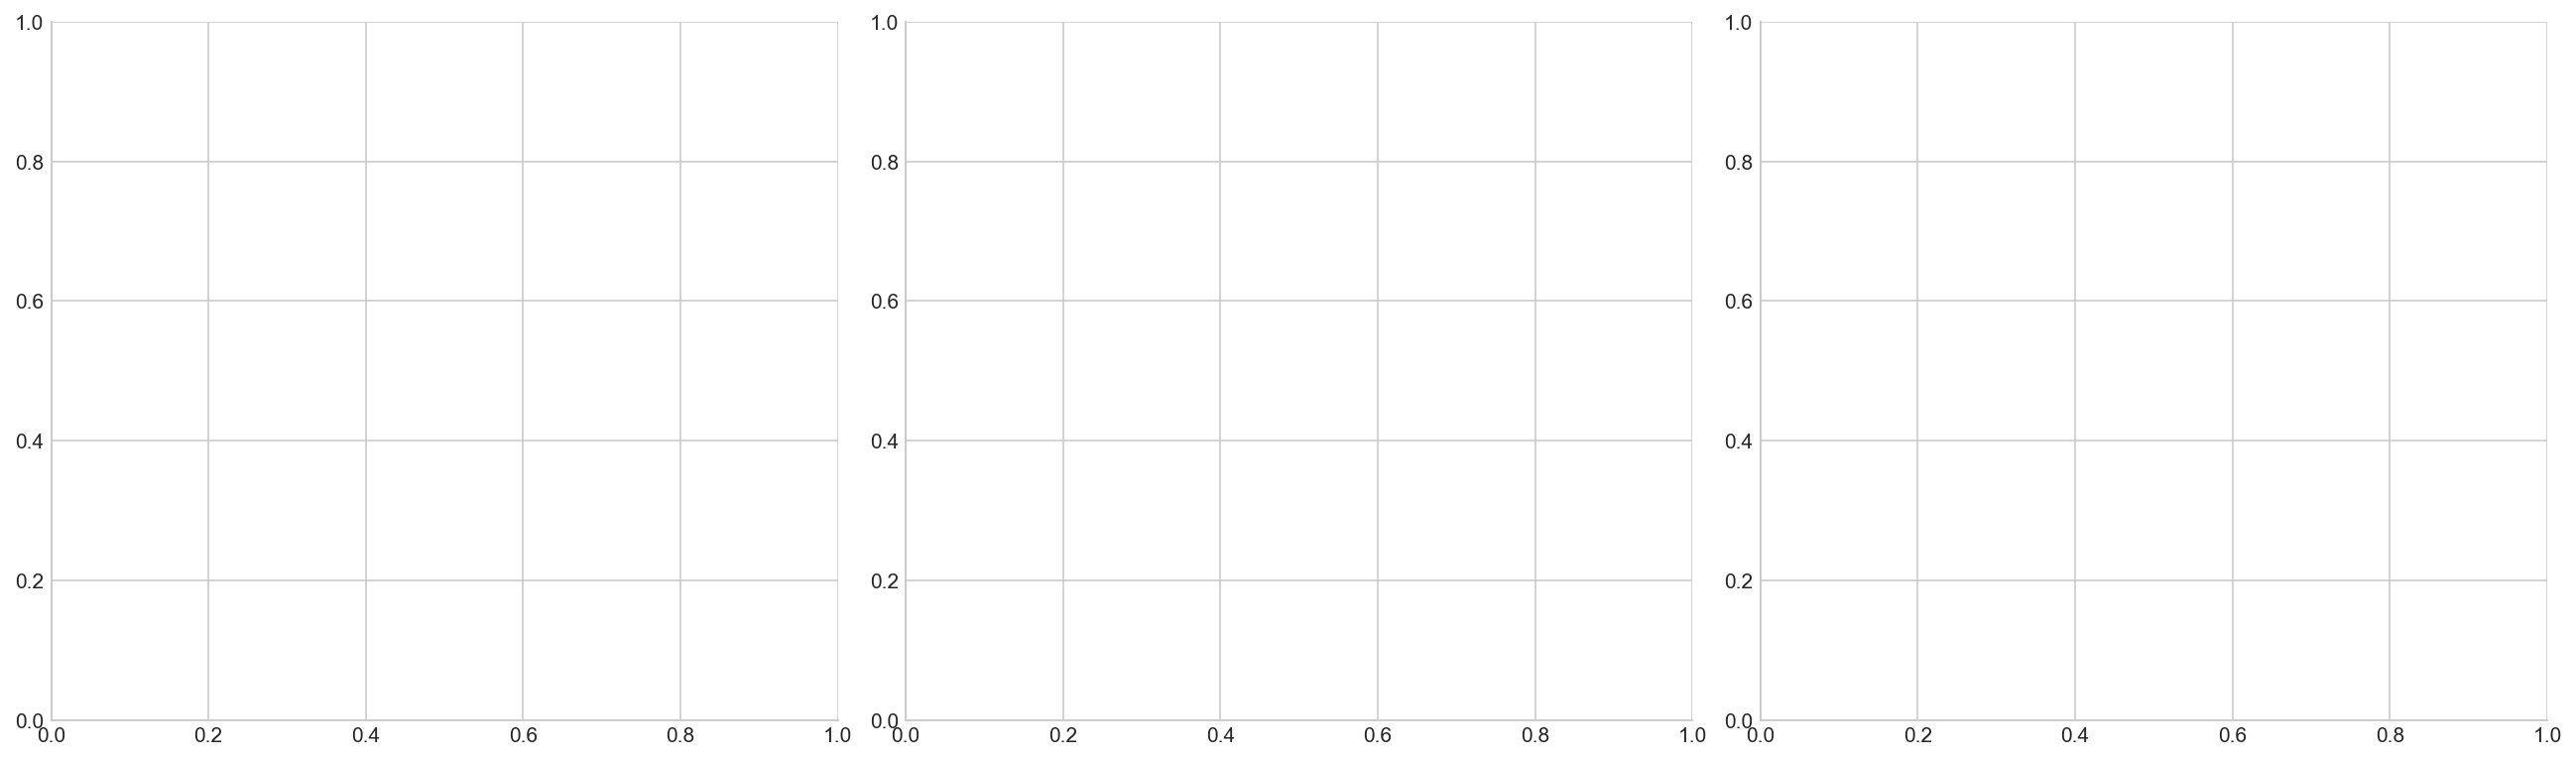

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(17.2, 5.0), constrained_layout=True)
x = paper_nonref["n_samples"].to_numpy(dtype=int)

ax = axes[0]
y = paper_nonref["mean_abs_diff_vs_reference"].to_numpy(dtype=float)
lo = paper_nonref["mean_abs_diff_ci_low"].to_numpy(dtype=float)
hi = paper_nonref["mean_abs_diff_ci_high"].to_numpy(dtype=float)
ax.plot(x, y, color="#1F4E79", marker="o", linewidth=2.5)
ax.fill_between(x, lo, hi, color="#1F4E79", alpha=0.18)
for xi, yi in zip(x, y):
    ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_title("Prefix-level estimation error")
ax.set_xlabel("Continuation samples per prefix")
ax.set_ylabel(f"Mean abs. error vs {reference_budget}-sample reference")
ax.set_xticks(x)
ax.grid(True, axis="y", alpha=0.25)

ax = axes[1]
for metric, low_col, high_col, label, color in [
    ("frac_within_0_05", "frac_within_0_05_ci_low", "frac_within_0_05_ci_high", "|error| <= 0.05", "#C44E52"),
    ("frac_within_0_10", "frac_within_0_10_ci_low", "frac_within_0_10_ci_high", "|error| <= 0.10", "#55A868"),
]:
    y = paper_nonref[metric].to_numpy(dtype=float)
    lo = paper_nonref[low_col].to_numpy(dtype=float)
    hi = paper_nonref[high_col].to_numpy(dtype=float)
    ax.plot(x, y, color=color, marker="o", linewidth=2.3, label=label)
    ax.fill_between(x, lo, hi, color=color, alpha=0.14)
ax.set_title("Prefix-level stability")
ax.set_xlabel("Continuation samples per prefix")
ax.set_ylabel("Fraction of prefixes")
ax.set_xticks(x)
ax.set_ylim(0.0, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc="lower right", frameon=True)
ax.grid(True, axis="y", alpha=0.25)

ax = axes[2]
for metric, low_col, high_col, label, color in [
    ("peak_within_one", "peak_within_one_ci_low", "peak_within_one_ci_high", "Peak sentence within one", "#4C72B0"),
    (jump_within_metric, jump_within_low_col, jump_within_high_col, jump_curve_label, "#8172B3"),
]:
    y = paper_nonref[metric].to_numpy(dtype=float)
    lo = paper_nonref[low_col].to_numpy(dtype=float)
    hi = paper_nonref[high_col].to_numpy(dtype=float)
    ax.plot(x, y, color=color, marker="o", linewidth=2.3, label=label)
    ax.fill_between(x, lo, hi, color=color, alpha=0.14)
ax.set_title("Structural agreement")
ax.set_xlabel("Continuation samples per prefix")
ax.set_ylabel("Agreement with reference")
ax.set_xticks(x)
ax.set_ylim(0.0, 1.02)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(loc="lower right", frameon=True)
ax.grid(True, axis="y", alpha=0.25)

fig.suptitle("Localization sampling-budget ablation on 100 deceptive short examples", fontsize=15, y=1.03)
maybe_savefig(fig, "figure_main_budget_tradeoffs.png")
plt.show()


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Optional: if you already have a paper style helper, keep this.
# apply_paper_style()

# --- Prepare data ---
budgets_sorted = sorted(eval_budgets)
box_data = [
    example_budget_mae.loc[
        example_budget_mae["n_samples"].eq(budget),
        "mean_abs_diff_vs_reference",
    ].to_numpy(dtype=float)
    for budget in budgets_sorted
]

# --- Figure ---
fig, ax = plt.subplots(figsize=(5.8, 3.6), constrained_layout=True)

box = ax.boxplot(
    box_data,
    positions=np.arange(1, len(budgets_sorted) + 1),
    widths=0.58,
    patch_artist=True,
    showfliers=False,
    whis=(5, 95),  # cleaner for paper figures; use 1.5 if you want standard Tukey whiskers
    medianprops={"color": "black", "linewidth": 1.8},
    boxprops={"linewidth": 1.2},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
)

# Use a consistent, paper-friendly fill
for patch in box["boxes"]:
    patch.set_facecolor("#4C72B0")
    patch.set_alpha(0.35)
    patch.set_edgecolor("black")

# --- Labels / styling ---
#ax.set_title("Example-level heterogeneity in localization error", pad=8)
ax.set_xlabel("Continuation samples per prefix")
ax.set_ylabel(f"Mean absolute error vs. {reference_budget}-sample reference")

ax.set_xticks(np.arange(1, len(budgets_sorted) + 1))
ax.set_xticklabels([str(b) for b in budgets_sorted])

ax.grid(True, axis="y", alpha=0.22, linewidth=0.8)
ax.grid(False, axis="x")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Optional: tighten the visible y-range a bit for papers
# y_max = max(np.nanmax(v) for v in box_data)
# ax.set_ylim(0, y_max * 1.08)
plt.savefig('figure_example_level_heterogeneity_boxplot.png')
maybe_savefig(fig, "figure_example_level_heterogeneity_boxplot.png")
plt.show()

NameError: name 'eval_budgets' is not defined

In [6]:
paper_table_display = pd.DataFrame(
    {
        "Samples / prefix": paper_nonref["n_samples"].astype(int),
        "Mean abs. error vs ref": [
            fmt_ci(center, low, high)
            for center, low, high in zip(
                paper_nonref["mean_abs_diff_vs_reference"],
                paper_nonref["mean_abs_diff_ci_low"],
                paper_nonref["mean_abs_diff_ci_high"],
            )
        ],
        "Prefixes within 0.05": [
            fmt_ci_pct(center, low, high)
            for center, low, high in zip(
                paper_nonref["frac_within_0_05"],
                paper_nonref["frac_within_0_05_ci_low"],
                paper_nonref["frac_within_0_05_ci_high"],
            )
        ],
        "Prefixes within 0.10": [
            fmt_ci_pct(center, low, high)
            for center, low, high in zip(
                paper_nonref["frac_within_0_10"],
                paper_nonref["frac_within_0_10_ci_low"],
                paper_nonref["frac_within_0_10_ci_high"],
            )
        ],
        "Peak sentence agreement (within 1)": [
            fmt_ci_pct(center, low, high)
            for center, low, high in zip(
                paper_nonref["peak_within_one"],
                paper_nonref["peak_within_one_ci_low"],
                paper_nonref["peak_within_one_ci_high"],
            )
        ],
        jump_metric_label: [
            fmt_ci_pct(center, low, high)
            for center, low, high in zip(
                paper_nonref[jump_within_metric],
                paper_nonref[jump_within_low_col],
                paper_nonref[jump_within_high_col],
            )
        ],
    }
)

display(paper_table_display.style.hide(axis="index"))
if jump_filtered_available:
    display(Markdown(f"_{jump_metric_note}_"))

latex_table = paper_nonref.copy()
latex_table["Samples / prefix"] = latex_table["n_samples"].astype(int)
latex_table["Mean abs. error vs ref"] = [
    fmt_ci(center, low, high)
    for center, low, high in zip(
        latex_table["mean_abs_diff_vs_reference"],
        latex_table["mean_abs_diff_ci_low"],
        latex_table["mean_abs_diff_ci_high"],
    )
]
latex_table["Prefixes within 0.05"] = [
    fmt_ci_pct(center, low, high)
    for center, low, high in zip(
        latex_table["frac_within_0_05"],
        latex_table["frac_within_0_05_ci_low"],
        latex_table["frac_within_0_05_ci_high"],
    )
]
latex_table["Prefixes within 0.10"] = [
    fmt_ci_pct(center, low, high)
    for center, low, high in zip(
        latex_table["frac_within_0_10"],
        latex_table["frac_within_0_10_ci_low"],
        latex_table["frac_within_0_10_ci_high"],
    )
]
latex_table["Peak sentence agreement (within 1)"] = [
    fmt_ci_pct(center, low, high)
    for center, low, high in zip(
        latex_table["peak_within_one"],
        latex_table["peak_within_one_ci_low"],
        latex_table["peak_within_one_ci_high"],
    )
]
latex_table[jump_metric_label] = [
    fmt_ci_pct(center, low, high)
    for center, low, high in zip(
        latex_table[jump_within_metric],
        latex_table[jump_within_low_col],
        latex_table[jump_within_high_col],
    )
]

smaller_better_cols = ["Mean abs. error vs ref"]
larger_better_cols = [
    "Prefixes within 0.05",
    "Prefixes within 0.10",
    "Peak sentence agreement (within 1)",
    jump_metric_label,
]

latex_rows = []
best_budget = int(paper_nonref.loc[paper_nonref['mean_abs_diff_vs_reference'].idxmin(), 'n_samples'])
for _, row in latex_table.iterrows():
    formatted = {
        "Samples / prefix": int(row["Samples / prefix"]),
        "Mean abs. error vs ref": row["Mean abs. error vs ref"],
        "Prefixes within 0.05": row["Prefixes within 0.05"],
        "Prefixes within 0.10": row["Prefixes within 0.10"],
        "Peak sentence agreement (within 1)": row["Peak sentence agreement (within 1)"],
        jump_metric_label: row[jump_metric_label],
    }
    if int(row["Samples / prefix"]) == best_budget:
        for key in formatted:
            if key != "Samples / prefix":
                formatted[key] = f"\\textbf{{{formatted[key]}}}"
    latex_rows.append(formatted)

latex_df = pd.DataFrame(latex_rows)
paper_table_latex = latex_df.to_latex(index=False, escape=False)
print(paper_table_latex)


NameError: name 'paper_nonref' is not defined

In [7]:
env_table = pd.DataFrame(
    {
        "Environment": env_order,
        "Selected examples": selected_examples_by_env.loc[env_order].astype(int).tolist(),
        "Reference prefixes": reference_prefixes_by_env.loc[env_order].astype(int).tolist(),
        f"MAE @ {eval_budgets[0]}": env_budget_mae.loc[env_order, eval_budgets[0]].map(lambda x: f"{x:.3f}").tolist(),
        f"MAE @ 25": env_budget_mae.loc[env_order, 25].map(lambda x: f"{x:.3f}").tolist(),
        f"MAE @ 50": env_budget_mae.loc[env_order, 50].map(lambda x: f"{x:.3f}").tolist(),
        f"Within 0.10 @ 50": env_budget_cover10.loc[env_order, 50].map(lambda x: fmt_pct(x)).tolist(),
    }
)
display(env_table.style.hide(axis="index"))

hard_examples_table = (
    example_budget_mae.loc[example_budget_mae["n_samples"].eq(smallest_budget)]
    .sort_values("mean_abs_diff_vs_reference", ascending=False)
    .head(8)
    .assign(sentence_preview=lambda d: d["example_id"].map(str))
)
hard_examples_table = hard_examples_table[["env_name", "example_id", "mean_abs_diff_vs_reference"]].copy()
hard_examples_table["example_id"] = hard_examples_table["example_id"].map(lambda text: wrap_text(text, width=74))
hard_examples_table["mean_abs_diff_vs_reference"] = hard_examples_table["mean_abs_diff_vs_reference"].map(lambda x: f"{x:.3f}")
hard_examples_table.columns = ["Environment", "Hardest example IDs at 10 samples", "Example-level mean abs. error"]
display(hard_examples_table.style.hide(axis="index"))


NameError: name 'env_order' is not defined